In [7]:
import numpy as np

import matplotlib as mpl
import modules.tools as tools
import modules.models as models

import scipy.sparse.linalg as sla
import sys

import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
import os
import pickle
print(os.path.dirname(os.getcwd()))

/Users/alexanderlau/Documents/Science/Projects/NLSM_flat_band/NLSM_flat_band_files


In [9]:
from tqdm.notebook import tqdm # to have a progress bar for the loop

In [10]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=16)

In [11]:
s0 = np.eye(2)
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])

In [12]:
from numpy import cos, sin, pi, exp, sqrt

# Finite Model with strain

In [13]:
def H_full_strain(ky, Lx, Lz, R, t1, t2, t=1., d=1., sp_term=False, periodic_x=True):
    ''' Returns the tight-binding Hamiltonian of the strained toy model
        for a supercell of Lz sites at momentum (kx,ky).
        
        This model includes all strain terms, including the mixed-orbital s-p terms.
        
        The line z=0 (x=0) goes through the center of the slab:
        for Lz (Lx) even: z=0 (x=0) is between the two central sites
        for Lz (Lx) odd: z=0 (x=0) is at the central site.
    '''
    H_strain = np.zeros((2*Lz*Lx,2*Lz*Lx), dtype='complex')

    # uniform diagonal terms
    for j in range(Lx):
        for i in range(Lz):
            H_strain[(2*Lz*j + 2*i):(2*Lz*j + 2*i + 2), 
                     (2*Lz*j + 2*i):(2*Lz*j + 2*i + 2)] += (6.*t - t1 - 2.*t*cos(d*ky))*sz

    # uniform hopping terms in z direction
    hopp = np.zeros((2*Lz*Lx,2*Lz*Lx), dtype='complex')
    for j in range(Lx):
        for i in range(Lz-1):
            hopp[(2*Lz*j + 2*i):(2*Lz*j + 2*i + 2),
                 (2*Lz*j + 2*(i+1)):(2*Lz*j + 2*(i+1) + 2)] += -sz*t - 1j*t2*sx

    # hopping terms in x direction
    for i in range(Lz):
        for j in range(Lx-1):
            # uniform terms 
            hopp[(2*Lz*j + 2*i):(2*Lz*j + 2*i + 2),
                 (2*Lz*(j+1) + 2*i):(2*Lz*(j+1) + 2*i + 2)] += -t * (1.-(i-(Lz-1)/2.)*d/R) * sz
            # non-uniform terms
            if sp_term:
                hopp[(2*Lz*j + 2*i):(2*Lz*j + 2*i + 2),
                     (2*Lz*(j+1) + 2*i):(2*Lz*(j+1) + 2*i + 2)] += -1.j*t2 * (1.-(j-Lx/2+1)*d/(2*R)) * sx
        # periodic BC in x for uniform terms
        if periodic_x:
            hopp[(2*i):(2*i + 2),
                 (2*Lz*(Lx-1) + 2*i):(2*Lz*(Lx-1) + 2*i + 2)] += -t * (1.-(i-(Lz-1)/2.)*d/R) * sz
    
    H_strain += hopp + np.conjugate(np.transpose(hopp))
            
    return H_strain

## Sizable strain with and without $sp$ terms

Ensure that $L_z/2 < R$.

In [14]:
R = 200
t1 = 0.25
t2 = 0.8
Lz = 100

Nky = 101
kys = np.linspace(-pi,pi,Nky)

Lx = 20
n = 20 # how many states

### (i) Without $sp$ terms

In [ ]:
evals1 = np.zeros((Nky,n))
evecs1 = np.zeros((Nky,2*Lz*Lx,n), dtype='complex')

sp_term = False


for i,ky in tqdm(list(enumerate(kys))):
    evals1[i,:], evecs1[i,:,:] = sla.eigsh(H_full_strain(ky, Lx, Lz, R, t1, t2, 
                                                              sp_term=sp_term, periodic_x=False),
                                          k=n, sigma=1e-10, which='LM')

In [ ]:
for i in range(Nky):
    sorted_indices = np.argsort(evals1[i,:])
    evals1[i,:] = evals1[i,sorted_indices]
    evecs1[i,:,:] = np.transpose(evecs1[i,:,sorted_indices])

In [ ]:
plt.figure(figsize=(6,6))
plt.title("$L_x=20$, $L_z=100$, without sp term")
plt.plot(kys, evals1, c='blue')#, ls='', marker='.', c='blue')
plt.xlabel('$k_y$')
plt.ylabel('$E$')
plt.ylim(-0.22,0.22)
plt.xlim(-1.5,1.5)

### (ii) With $sp$ terms

In [ ]:
evals2 = np.zeros((Nky,n))
evecs2 = np.zeros((Nky,2*Lz*Lx,n), dtype='complex')

sp_term = True

for i,ky in tqdm(list(enumerate(kys))):
    evals2[i,:], evecs2[i,:,:] = sla.eigsh(H_full_strain(ky, Lx, Lz, R, t1, t2, 
                                                              sp_term=sp_term, periodic_x=False),
                                          k=n, sigma=1e-10, which='LM')

In [ ]:
for i in range(Nky):
    sorted_indices = np.argsort(evals2[i,:])
    evals2[i,:] = evals2[i,sorted_indices]
    evecs2[i,:,:] = np.transpose(evecs2[i,:,sorted_indices])

In [ ]:
plt.figure(figsize=(6,6))
plt.title("$L_x=20$, $L_z=100$, with sp term")
plt.plot(kys, evals2, c='blue')
plt.xlabel('$k_y$')
plt.ylabel('$E$')
plt.ylim(-0.22,0.22)
plt.xlim(-1.5,1.5)

Look at the flat-band states

In [ ]:
def density_z(evec, Lz, Lx):
    density = np.zeros(Lz) 
    
    for i in range(Lz):
        for j in range(Lx):
            density[i] += (abs(evec[2*Lz*j + 2*i])**2 + abs(evec[2*Lz*j + 2*i + 1])**2)/Lx
        
    return density    

In [ ]:
k=50
n=10
print(evals2[k,n])
print(kys[k])

state = np.sqrt(density_z(evecs2[k,:,n], Lz, Lx))

In [ ]:
plt.plot(state)
plt.ylabel('$|\psi(z)|$')
plt.xlabel('$z$')

## Load spectrum from cluster

In [22]:
path = os.path.dirname(os.getcwd()) + '/data/'

In [23]:
print(path)

/Users/alexanderlau/Documents/Science/Projects/NLSM_flat_band/NLSM_flat_band_files/data/


In [24]:
# Read in the data
name = 'spectrum_strained_Lx100_Lz100_R20000_without_sp'
fb = open(path + name + '.p','rb')
params_save0 = pickle.load(fb)
kys0 = pickle.load(fb)
evals0 = pickle.load(fb)

name = 'spectrum_strained_Lx100_Lz100_R200_without_sp'
fb = open(path + name + '.p','rb')
params_save1 = pickle.load(fb)
kys1 = pickle.load(fb)
evals1 = pickle.load(fb)

name = 'spectrum_strained_Lx100_Lz100_R200_with_sp'
fb = open(path + name + '.p','rb')
params_save2 = pickle.load(fb)
kys2 = pickle.load(fb)
evals2 = pickle.load(fb)

In [25]:
t1 = params_save0['t1']
t2 = params_save0['t2']
Lx = params_save0['Lx']
Lz = params_save0['Lz']

(-1.0, 1.0)

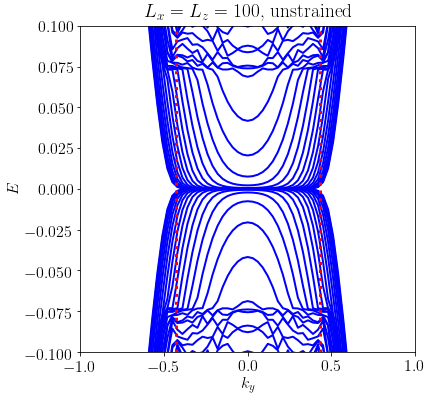

In [26]:
plt.figure(figsize=(6,6))
plt.title("$L_x=L_z=100$, unstrained")
plt.plot(kys0, evals0, c='blue', lw=2)
plt.axvline(-0.43, c='red', ls=':', lw=3)
plt.axvline(0.43, c='red', ls=':', lw=3)
#plt.axhline(0.001, c='red', ls=':', lw=3)
plt.xlabel('$k_y$')
plt.ylabel('$E$')
plt.ylim(-0.1,0.1)
plt.xlim(-1.0,1.0)

(-1.0, 1.0)

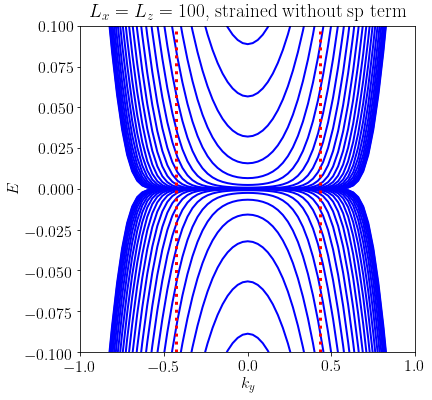

In [27]:
plt.figure(figsize=(6,6))
plt.title("$L_x=L_z=100$, strained without sp term")
plt.plot(kys1, evals1, c='blue', lw=2)
plt.axvline(-0.43, c='red', ls=':', lw=3)
plt.axvline(0.43, c='red', ls=':', lw=3)
plt.xlabel('$k_y$')
plt.ylabel('$E$')
plt.ylim(-0.1,0.1)
plt.xlim(-1.0,1.0)

(-1.0, 1.0)

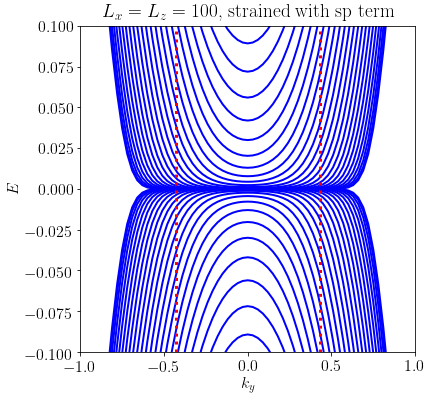

In [28]:
plt.figure(figsize=(6,6))
plt.title("$L_x=L_z=100$, strained with sp term")
plt.plot(kys2, evals2, c='blue', lw=2)
plt.axvline(-0.43, c='red', ls=':', lw=3)
plt.axvline(0.43, c='red', ls=':', lw=3)
plt.xlabel('$k_y$')
plt.ylabel('$E$')
plt.ylim(-0.1,0.1)
plt.xlim(-1.0,1.0)